# 8. An example of Automatic Differentiation

Pauli propagation has promise in optimizing variational models because its elementary operations are very simple and automatically differentiable. Additionally, it may be the case that strongly truncated simulations still yield final parameters that translate to high-quality quantum circuits on, for example, a quantum computer. This means that we could (perhaps) very cheaply train/optimize, and then deploy the learned model on a different classical or quantum method. There are some initial indications of this being possible, but they require further exploration. 

In this notebook, we demonstrate how to calculate gradients of a quantum circuit using Pauli propagation: first with the general-purpose `ForwardDiff.jl` package, then with PauliPropagation's own `rewindgradient` function. We also compare both to the simplest approach, finite differences, to see how the runtime scales with the number of parameters and how much accuracy truncation costs each method.

In [1]:
using Pkg
Pkg.activate(".")
using PauliPropagation

  Activating project at `~/Projects/PauliPropagation.jl/examples`


Let us set up a simulation:

In [2]:
nq = 64

topology = bricklayertopology(nq);

We define a transverse field Hamiltonian, whose derivative we will compute. This could be used within a variational energy minimization routine to find its ground state. 

The Hamiltonian here reads $H = \sum_{i}X_i + \sum_{\langle i, j\rangle}Z_iZ_j$ where $ \langle i, j\rangle$ denotes neighbors on the topology.

In [3]:
H = PauliSum(nq)

for qind in 1:nq
    add!(H, :X, qind, 1.0)
end

for pair in topology
    add!(H, [:Z, :Z], collect(pair), 1.0)
end

H

PauliSum(nqubits: 64, 127 Pauli terms:
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IZZIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIXIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIXIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIXIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIXIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIXIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
 1.0 * IIIIIIIIIIIIIIIIIIII...
  ⋮)

Define some generic quantum circuit

In [4]:
nl = 4

# if we begin with the ZZ layer, it commutes with the |0> state and gives zero gradients
circuit = tfitrottercircuit(nq, nl; topology=topology, start_with_ZZ=false)
nparams = countparameters(circuit)

508

Importantly, we need to set our truncations. Depending on which package and which method you are using to compute your gradients, you can use different truncations. 

`ReverseDiff.jl` for example is a sophisticated package for automatic _reverse-mode_ differentiation (others may or may not work better). It will build a computational graph that it then differentiates using the chain rule. This is how large-scale neural networks are trained, and is commonly referred to as gradient _backpropagation_. The challenge here is that the fastest gradients are achieved with a _compiled_ version of the gradient function where the graph for the chain rule is computed once (to the best of our knowledge). In that case, only truncations during the initial computation will be respected. Truncations that we think work well here are `max_weight`, `max_freq`, and `max_sins`, as they do not depend on the particular parameters of the quantum circuit. On the other hand, which paths are explore with truncations such as `min_abs_coeff` will not be updated (again, to the best of our knowledge) as the gradients are computed. If you want to use such parameter-dependent truncations, you may need to use un-compiled gradient functions.

`Mooncake.jl` is an up-and-coming package written fully in Julia that differentiates _the code itself_. It allows for reverse-mode differentiation with truncations like `min_abs_coeff` working and being differentiated as intended. We hope to provide a tutorial for this library soon.

`ForwardDiff.jl` is a straight-up improvement over manual numerical differentiation, both in terms of speed and accuracy. Compared to reverse-mode differentiation libraries it is slower for circuits with more than several dozen parameters, but it requires very little additional memory. We will use it for this notebook.

PauliPropagation.jl also provides its own gradient function, `rewindgradient`, shown further below. It is compatible with truncations, does not require a compiled graph and approximately twice the memory of one propagation. However, it does not differentiate arbitrary cost functions. Only standard expectation values for now.

Generate some generic parameters:

In [5]:
using Random
Random.seed!(42)
thetas = randn(nparams);

One expectation evaluation

In [6]:
min_abs_coeff = 1e-4
max_weight = 5

@time psum = propagate(circuit, H, thetas; min_abs_coeff, max_weight);
overlapwithzero(psum)

  1.070803 seconds (2.49 M allocations: 108.517 MiB, 0.52% gc time, 99.18% compilation time)


7.26631983654383

**Note**: To make these following functionsfaster, you should look into `let` blocks for local variable namespaces. You will want to define _closures_ and refrain from using global variables.

#### What does not work:

Now wrap these steps into a function that takes only `thetas` as argument. (keep in mind our comment about using `let` blocks)

This loss function does not work because the `ForwardDiff` package needs to propagate its custom coefficient type. But `H` is already strictly typed. So the following loss function would not be automatically differentiable.

In [7]:
function naivelossfunction(thetas)
    # this function is not fully type-stable because min_abs_coeff and max_weight are global variables
    psum = propagate(circuit, H, thetas; min_abs_coeff, max_weight);
    return overlapwithzero(psum)
end

naivelossfunction (generic function with 1 method)

The loss works

In [8]:
@time naivelossfunction(thetas)

  0.258566 seconds (3.41 M allocations: 153.052 MiB, 4.43% gc time, 96.67% compilation time)


7.26631983654383

But the gradient would break with a cryptic error message.

In [9]:
# using Pkg; Pkg.add("ForwardDiff")
using ForwardDiff: gradient

## this errors 
# gradient(naivelossfunction, thetas)

#### What works:

To create a loss function that indeed works, we need the propagating Hamiltonian to have the correct coefficient type within the loss function. What tends to work is to type the coefficients in the Pauli sum to the element type of `thetas`, but this will not always work. In this case, it will make everything differentiable.

Then we need to use the `propagate!()` function because otherwise the ForwardDiff library errors or yields zero gradients because we copy the Pauli sum while that library is accumulating the derrivative. Annoying... we agree! We will keep an eye out for better options.

For maximal performance, we will want to make all functions type stable, which can be achieved by a function _closure_ or function _factory_: A function that outputs a function. In this case, we want to output a loss function that has all arguments other than `thetas` pre-loaded.

In [10]:
function generate_lossfunction(circuit, H, min_abs_coeff, max_weight)
    
        function lossfunction(thetas)
        # differentiation libraries use custom types to trace through the computation
        # we need to make all of our objects typed like that so that nothing breaks
        CoeffType = eltype(thetas)

        # convert H to use the correct coefficient type
        # otherwise it would error like above
        grad_ready_H = convertcoefftype(CoeffType, H)

        # be also need to run the in-place version with `!`, because by default we copy the Pauli sum
        output_H = propagate!(circuit, grad_ready_H, thetas; min_abs_coeff, max_weight);
        return overlapwithzero(output_H)
    end

    return lossfunction
end

generate_lossfunction (generic function with 1 method)

In [11]:
# define the loss function that works with AD
lossfunction = generate_lossfunction(circuit, H, min_abs_coeff, max_weight);

In [12]:
@time lossfunction(thetas)

  0.026959 seconds (432.55 k allocations: 7.642 MiB, 62.90% compilation time)


7.26631983654383

And gradients work.

In [13]:
# the gradients of the first ZZ layer is 
@time gradient(lossfunction, thetas)

  2.078184 seconds (26.50 M allocations: 2.587 GiB, 10.49% gc time, 54.40% compilation time)


508-element Vector{Float64}:
 -0.6772329930789089
 -0.22543783632035608
 -0.42292925319813446
 -0.4243076836337615
 -0.7523379732310989
 -0.07792066987114322
 -0.8515536079185417
  0.01990979942877011
  0.8974187316400088
 -0.25922854058847183
  ⋮
  0.8133558792992438
  0.24969214893578057
  0.6969899813204755
  0.17190365988833814
  0.6511464180672394
  0.03797818611225978
  0.3563370395924771
 -0.21643500323976758
  0.046996169676417704

### A simpler alternative: `rewindgradient`

PauliPropagation also has a gradient function built specifically for circuits like this one: `rewindgradient`. It computes the expectation value and the full gradient together, in a single pass over the circuit, directly on a `VectorPauliSum` — no coefficient-type conversion and no closures needed for speed.

In [14]:
@time expec, grad = rewindgradient(circuit, VectorPauliSum(H), thetas, overlapwithzero; min_abs_coeff, max_weight)
expec

  3.233736 seconds (13.94 M allocations: 651.500 MiB, 1.31% gc time, 99.09% compilation time)


2.8991472472448954

### Comparing to finite differences

How does `rewindgradient` compare to the other two ways of getting a gradient we've seen above — `ForwardDiff`, and the simplest approach of all, finite differences (perturbing each parameter one at a time)? Two things matter in practice: how the runtime scales as the circuit gets more parameters, and how much accuracy truncation costs each method. We use a smaller example below so this runs quickly.

In [15]:
function finitedifferencegradient(circuit, psum, thetas, overlapfunc; eps=1e-6, kwargs...)
    grad = zeros(length(thetas))
    for i in eachindex(thetas)
        thetas_plus = copy(thetas); thetas_plus[i] += eps
        thetas_minus = copy(thetas); thetas_minus[i] -= eps
        fplus = overlapfunc(propagate(circuit, psum, thetas_plus; kwargs...))
        fminus = overlapfunc(propagate(circuit, psum, thetas_minus; kwargs...))
        grad[i] = (fplus - fminus) / (2eps)
    end
    return grad
end

function forwarddiffgradient(circuit, psum, thetas, overlapfunc; kwargs...)
    function lossfunction(x)
        CoeffType = eltype(x)
        grad_ready_psum = convertcoefftype(CoeffType, psum)
        output_psum = propagate!(circuit, grad_ready_psum, x; kwargs...)
        return overlapfunc(output_psum)
    end
    return gradient(lossfunction, thetas)
end

forwarddiffgradient (generic function with 1 method)

In [16]:
# a smaller example so the comparisons below run quickly
nq_small = 8
topology_small = bricklayertopology(nq_small)
H_small = PauliSum(nq_small)
for qind in 1:nq_small
    add!(H_small, :X, qind, 1.0)
end
for pair in topology_small
    add!(H_small, [:Z, :Z], collect(pair), 1.0)
end;

**Runtime vs. number of parameters.** A finite difference needs two extra propagations per parameter (one nudged up, one down). `ForwardDiff` needs only a single pass, but every number inside that pass now carries one extra value per parameter, so that single pass gets more expensive as the parameter count grows. `rewindgradient` needs exactly one pass over the circuit, and that pass doesn't get any more expensive as the number of parameters grows.

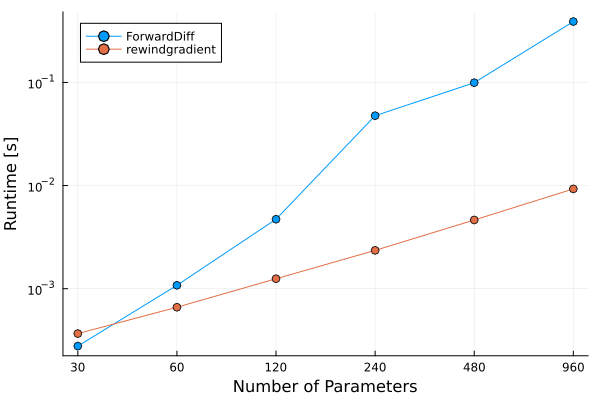

In [17]:
# using Pkg; Pkg.add("Plots")
using Plots

Random.seed!(4)

# warm up so compilation time doesn't show up in the timings below
for l in (2, 4)
    warmup_circuit = tfitrottercircuit(nq_small, l; topology=topology_small, start_with_ZZ=false)
    warmup_thetas = randn(countparameters(warmup_circuit))
    forwarddiffgradient(warmup_circuit, H_small, warmup_thetas, overlapwithzero; min_abs_coeff=1e-4)
    rewindgradient(warmup_circuit, VectorPauliSum(H_small), warmup_thetas, overlapwithzero; min_abs_coeff=1e-4);
end

nparams_list = Int[]
t_fad_list = Float64[]
t_rg_list = Float64[]

for nl_small in (2, 4, 8, 16, 32, 64)
    circuit_small = tfitrottercircuit(nq_small, nl_small; topology=topology_small, start_with_ZZ=false)
    thetas_small = randn(countparameters(circuit_small))

    push!(nparams_list, countparameters(circuit_small))
    push!(t_fad_list, @elapsed forwarddiffgradient(circuit_small, H_small, thetas_small, overlapwithzero; min_abs_coeff=1e-4))
    push!(t_rg_list, @elapsed rewindgradient(circuit_small, VectorPauliSum(H_small), thetas_small, overlapwithzero; min_abs_coeff=1e-4))
end

plot(xscale=:log10, yscale=:log10, xticks=(nparams_list, string.(nparams_list)), xlabel="Number of Parameters", ylabel="Runtime [s]", legend=:topleft)
plot!(nparams_list, t_fad_list, marker=:o, label="ForwardDiff")
plot!(nparams_list, t_rg_list, marker=:o, label="rewindgradient")

**Accuracy lost to truncation.** A finite difference runs the circuit twice per parameter — once nudged up, once down — and each of those two runs makes its own truncation decisions. Small differences in which terms get dropped between the two runs can swing the result a lot. `ForwardDiff` and `rewindgradient` both differentiate a single truncated run instead, so they tend to stay closer to the untruncated answer.

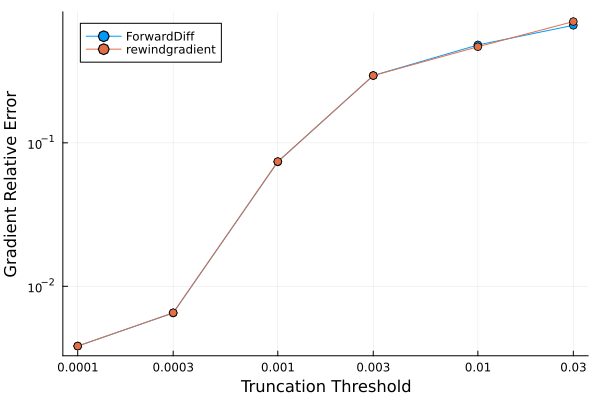

In [18]:
using LinearAlgebra

Random.seed!(4)
nl_acc = 10
circuit_acc = tfitrottercircuit(nq_small, nl_acc; topology=topology_small, start_with_ZZ=false)
thetas_acc = randn(countparameters(circuit_acc)) * 0.8

# an (almost) untruncated finite-difference gradient to serve as ground truth
grad_ref = forwarddiffgradient(circuit_acc, H_small, thetas_acc, overlapwithzero; min_abs_coeff=1e-9)

cutoffs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2]

fad_errors = Float64[]
rg_errors = Float64[]

for cutoff in cutoffs
    grad_fad = forwarddiffgradient(circuit_acc, H_small, thetas_acc, overlapwithzero; min_abs_coeff=cutoff)
    _, grad_rg = rewindgradient(circuit_acc, VectorPauliSum(H_small), thetas_acc, overlapwithzero; min_abs_coeff=cutoff)

    push!(fad_errors, norm(grad_fad - grad_ref) / norm(grad_ref))
    push!(rg_errors, norm(grad_rg - grad_ref) / norm(grad_ref))
end

plot(xscale=:log10, yscale=:log10, xticks=(cutoffs, string.(cutoffs)), xlabel="Truncation Threshold", ylabel="Gradient Relative Error", legend=:topleft)
plot!(cutoffs, fad_errors, marker=:o, label="ForwardDiff")
plot!(cutoffs, rg_errors, marker=:o, label="rewindgradient")

You are now ready to go! Plug either gradient function into your favorite optimizer and see what happens.

Remember: 
- These gradients are approximate when using truncation, and the size of that error is not the exactly the same for every method. We have found finite differences to be more inaccurate, but `ForwardDiff` and `rewindgradient` are very similar.
- `rewindgradient` needs only one pass over the circuit no matter how many parameters it has, so for circuits with many parameters it is typically both faster and more accurate under truncation than finite differences.
- Forward-mode differentiation (`ForwardDiff.jl`) scales linearly with the number of parameters, in addition to the extra runtime of simulating a deeper circuit.
- Reverse-mode differentiation can be faster, and drastically so when the gradient is compiled, at the cost of large memory overheads.
- You can also propagate each Pauli term in the Hamiltonian individually and add up their gradients. That can be easily multithreaded, but make sure that each `propagate` and `rewindgradient` are passed the `thread=false` kwarg to not compete with the outer threading. 